In [5]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2

In [9]:
training_data = datasets.FashionMNIST(
    root = 'data',
    train = True,
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)]),

)

test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)]),
)


100%|██████████| 26.4M/26.4M [03:14<00:00, 136kB/s] 
100%|██████████| 29.5k/29.5k [00:00<00:00, 86.5kB/s]
100%|██████████| 4.42M/4.42M [00:29<00:00, 148kB/s] 
100%|██████████| 5.15k/5.15k [00:00<00:00, 4.10MB/s]


torch.Size([1, 28, 28])
9


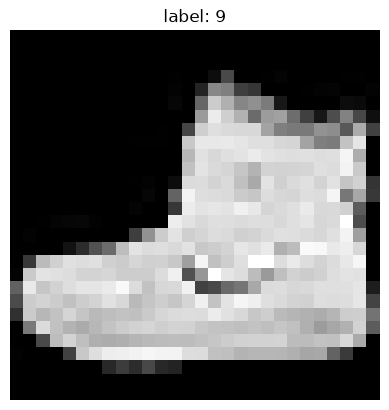

In [ ]:
import matplotlib.pyplot as plt
from torchvision import datasets
from torchvision.transforms import v2
import torch



img, label = training_data[0]

print(img.shape)   # torch.Size([1, 28, 28])
print(label)

plt.imshow(img.squeeze(), cmap="gray")
plt.title(f"label: {label}")
plt.axis("off")
plt.show()

magic: 2051
num_images: 60000
rows: 28
cols: 28
(60000, 28, 28)


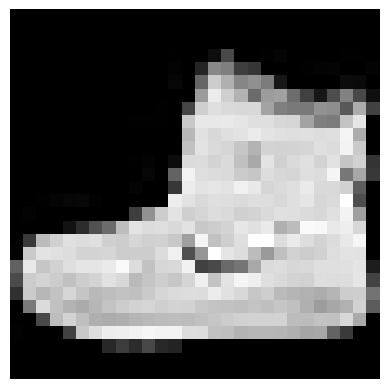

In [16]:
import gzip
import struct
import numpy as np
import matplotlib.pyplot as plt

image_path = "data/FashionMNIST/raw/train-images-idx3-ubyte.gz"

with gzip.open(image_path, "rb") as f:
    magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
    print("magic:", magic)
    print("num_images:", num_images)
    print("rows:", rows)
    print("cols:", cols)

    buffer = f.read()
    images = np.frombuffer(buffer, dtype=np.uint8)
    images = images.reshape(num_images, rows, cols)

print(images.shape)
# (60000, 28, 28)

plt.imshow(images[0], cmap="gray")
plt.axis("off")
plt.show()

In [18]:
batch_size = 64

train_dataloader = DataLoader(training_data, batch_size = batch_size) 
test_dataloader = DataLoader(test_data, batch_size = batch_size)

for X, y in test_dataloader:
    print(f"Shape of X [N, C, H, W]: {X.shape}")
    print(f"Shape of y: {y.shape} {y.dtype}")


Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape of y: torch.Size([64]) torch.int64
Shape of X [N, C, H, W]: torch.Size([64, 1, 28, 28])
Shape o

### Making Model

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available else "cpu"
print(f"Using {device} device")

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(784,512),
            nn.ReLU(),
            nn.Linear(512,512),
            nn.ReLU(),
            nn.Linear(512,10),

        )


    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork().to(device)
print(model)

Using mps device
NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_relu_stack): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): ReLU()
    (2): Linear(in_features=512, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [26]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 1e-3)

In [30]:
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        X , y = X.to(device), y.to(device)
        
        pred = model(X)
        loss = loss_fn(pred,y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")



In [31]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)
    num_batcehs = len(dataloader)
    model.eval()
    test_loss, acc = 0, 0
    with torch.no_grad():
        for X, y in dataloader:
            X, y = X.to(device) , y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred,y)
            acc  += (pred.argmax(1) == y).type(torch.float).sum().item()


    test_loss /= num_batcehs
    acc /= size
    print(f"Test Error: \n Accuracy: {(100*acc):>0.1f}%, Avg loss: {test_loss:>8f} \n")

        

In [32]:
epochs = 5
for t in range(epochs):
    print(f"Epoch {t+1}\n-----------------------------")
    train(train_dataloader, model, loss_fn, optimizer)
    test(test_dataloader, model, loss_fn)

print("Done.")


Epoch 1
-----------------------------
loss: 2.318911  [   64/60000]
loss: 2.304531  [ 6464/60000]
loss: 2.284774  [12864/60000]
loss: 2.269809  [19264/60000]
loss: 2.268522  [25664/60000]
loss: 2.223497  [32064/60000]
loss: 2.236952  [38464/60000]
loss: 2.205380  [44864/60000]
loss: 2.207299  [51264/60000]
loss: 2.166657  [57664/60000]
Test Error: 
 Accuracy: 36.6%, Avg loss: 2.174088 

Epoch 2
-----------------------------
loss: 2.190098  [   64/60000]
loss: 2.176313  [ 6464/60000]
loss: 2.124290  [12864/60000]
loss: 2.134929  [19264/60000]
loss: 2.094677  [25664/60000]
loss: 2.021142  [32064/60000]
loss: 2.055332  [38464/60000]
loss: 1.980339  [44864/60000]
loss: 1.986079  [51264/60000]
loss: 1.904945  [57664/60000]
Test Error: 
 Accuracy: 58.5%, Avg loss: 1.919022 

Epoch 3
-----------------------------
loss: 1.951755  [   64/60000]
loss: 1.916989  [ 6464/60000]
loss: 1.812759  [12864/60000]
loss: 1.851584  [19264/60000]
loss: 1.735602  [25664/60000]
loss: 1.676836  [32064/60000]
lo

In [34]:
torch.save(model.state_dict(), "model1.pth")
print("Saved PyTorch Model State to model1.pth")

Saved PyTorch Model State to model1.pth


In [ ]:
mdoel = NeuralNetwork().to(device)
model.load_state_dict(torch.load("model1.pth",weights_only = True))

<All keys matched successfully>

In [44]:
classes = [
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
]

model.eval()

x, y = test_data[12][0], test_data[12][1]
with torch.no_grad():
    x = x.to(device)
    pred = model(x)
    predicted, actual = classes[pred[0].argmax(0)] , classes[y]
    print(f"Predicted: '{predicted}', Actual: '{actual}'")

Predicted: 'Sneaker', Actual: 'Sneaker'


## Tensor

In [45]:
import torch
import numpy as np

In [49]:
data = np.array([[1,2],[3,4]])
print(data)
print(type(data))

[[1 2]
 [3 4]]
<class 'numpy.ndarray'>


In [ ]:
data = [[1,2],[3,4]]
x_data = torch.tensor(data)
print(x_data)
print(type(x_data))
print(x_data.dtype)
print(x_data.shape)


tensor([[1, 2],
        [3, 4]])
<class 'torch.Tensor'>
torch.int64
torch.Size([2, 2])


In [55]:
np_array = np.array(data)
x_np = torch.from_numpy(np_array)
print(x_np)
print(type(x_np))
print(x_np.dtype)
print(x_np.shape)


tensor([[1, 2],
        [3, 4]])
<class 'torch.Tensor'>
torch.int64
torch.Size([2, 2])


In [56]:
x_data == x_np

tensor([[True, True],
        [True, True]])

In [61]:
x_ones = torch.ones_like(x_data)
print(f"Ones Tensor: \n {x_ones} \n")
x_rand = torch.rand_like(x_data, dtype = torch.float)
print(f"Random Tensor: \n {x_rand} \n")

print(x_ones.dtype)
print(x_rand.dtype)



Ones Tensor: 
 tensor([[1, 1],
        [1, 1]]) 

Random Tensor: 
 tensor([[0.1021, 0.7982],
        [0.5038, 0.4416]]) 

torch.int64
torch.float32


In [62]:
shape = (2,3)
rand_tensor = torch.rand(shape)
ones_tensor = torch.ones(shape)
zeros_tensor = torch.zeros(shape)

print(f"Random Tensor: \n {rand_tensor} \n")
print(f"Ones Tensor: \n {ones_tensor} \n")
print(f"Zeros Tensor: \n {zeros_tensor} \n")


Random Tensor: 
 tensor([[0.2690, 0.6120, 0.7175],
        [0.1666, 0.8028, 0.5205]]) 

Ones Tensor: 
 tensor([[1., 1., 1.],
        [1., 1., 1.]]) 

Zeros Tensor: 
 tensor([[0., 0., 0.],
        [0., 0., 0.]]) 



In [ ]:
import torch 

In [75]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
device

'mps'

In [79]:
rand_tensor = rand_tensor.to(device)
rand_tensor

tensor([[0.2690, 0.6120, 0.7175],
        [0.1666, 0.8028, 0.5205]], device='mps:0')

In [80]:
print(f"Device on which tensor is stored on: {rand_tensor.device}")

Device on which tensor is stored on: mps:0


In [82]:
tensor = torch.ones(4,4)
print(f"First row: {tensor[0]}")
print(f"First column: {tensor[:,0]}")
print(f"Last column: {tensor[:,-1]}")

tensor[:,1] = 0

tensor

First row: tensor([1., 1., 1., 1.])
First column: tensor([1., 1., 1., 1.])
Last column: tensor([1., 1., 1., 1.])


tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

In [83]:
t1 = torch.cat([tensor,tensor,tensor], dim = 1)
t1

tensor([[1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.],
        [1., 0., 1., 1., 1., 0., 1., 1., 1., 0., 1., 1.]])

In [90]:
## matrix multiplication

y1 = tensor @ tensor.T
y2 = tensor.matmul(tensor.T)
y3 = torch.rand_like(y1)

torch.matmul(tensor,tensor.T, out  = y3)

z1 = tensor * tensor 
z2  = tensor.mul(tensor)
z3 = torch.rand_like(z1)

torch.mul(tensor,tensor, out= z3)

print(y1)
print()
print(y2)
print()
print(y3)
print()

print(z1)
print()
print(z2)
print()
print(z3)
print()



tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

tensor([[3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.],
        [3., 3., 3., 3.]])

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])

tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]])



In [92]:
agg = tensor.sum()
print(agg, type(agg))
agg_item = agg.item()
print(agg_item, type(agg_item))

tensor(12.) <class 'torch.Tensor'>
12.0 <class 'float'>


In [93]:
print(f"{tensor} \n")
tensor.add_(5)
print(f"{tensor} \n")


tensor([[1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.],
        [1., 0., 1., 1.]]) 

tensor([[6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.],
        [6., 5., 6., 6.]]) 



## Bridge with Numpy

In [94]:
t = torch.ones(5)
print(f"t: {t}")
n = t.numpy()
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.])
n: [1. 1. 1. 1. 1.]


In [95]:
t.add_(1)
print(f"t: {t}")
print(f"n: {n}")


t: tensor([2., 2., 2., 2., 2.])
n: [2. 2. 2. 2. 2.]


In [96]:
n = np.ones(5)
t = torch.from_numpy(n)

print(f"t: {t}")
print(f"n: {n}")

t: tensor([1., 1., 1., 1., 1.], dtype=torch.float64)
n: [1. 1. 1. 1. 1.]


In [97]:
np.add(n, 1 , out = n)
print(f"t: {t}")
print(f"n: {n}")

t: tensor([2., 2., 2., 2., 2.], dtype=torch.float64)
n: [2. 2. 2. 2. 2.]


## Data

In [9]:
import torch 
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root = "data",
    train = True,
    download = True,
    transform  = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)
test_data = datasets.FashionMNIST(
    root = "data",
    train = False,
    download = True,
    transform  = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale = True)])
)

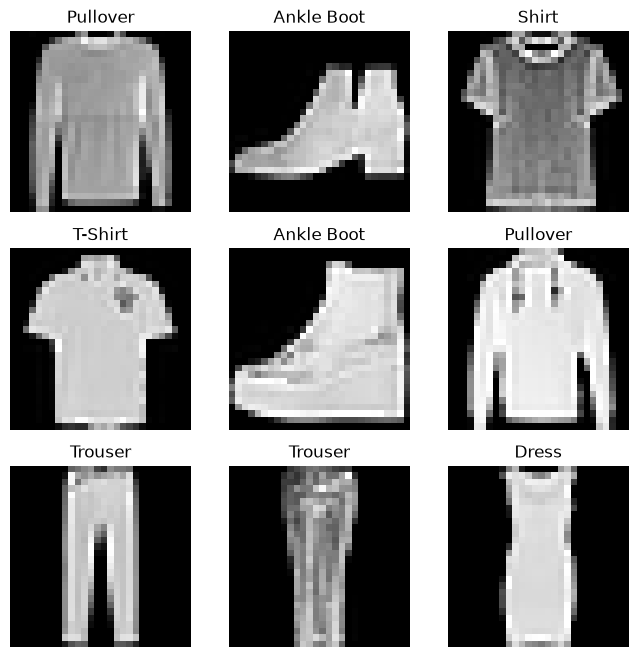

In [13]:
labels_map = {
    0: "T-Shirt",
    1: "Trouser",
    2: "Pullover",
    3: "Dress",
    4: "Coat",
    5: "Sandal",
    6: "Shirt",
    7: "Sneaker",
    8: "Bag",
    9: "Ankle Boot",
}
figure = plt.figure(figsize = (8,8))
cols, rows = 3,3
for i in range(1, cols*rows+1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows,cols,i) # 1~9
    plt.title(labels_map[label])
    plt.axis("off")
    plt.imshow(img.squeeze(),cmap="gray")
plt.show()

In [ ]:
# import struct
# import numpy as np
# import pandas as pd
# import gzip


# def open_idx_file(path):
#     path = str(path)
#     if path.endswith(".gz"):
#         return gzip.open(path, "rb")
#     else:
#         return open(path, "rb")


# def idx_labels_to_csv(label_path, csv_path):
#     with open_idx_file(label_path) as f:
#         # IDX label header: magic, num_labels
#         magic, num_labels = struct.unpack(">II", f.read(8))

#         print("magic:", magic)
#         print("num_labels:", num_labels)

#         if magic != 2049:
#             raise ValueError("라벨 IDX 파일이 아닙니다. magic number가 2049이어야 합니다.")

#         labels = np.frombuffer(f.read(), dtype=np.uint8)

#     if len(labels) != num_labels:
#         raise ValueError("header의 label 개수와 실제 label 개수가 다릅니다.")

#     df = pd.DataFrame({
#         "label": labels
#     })

#     df.to_csv(csv_path, index=False)

#     print(f"CSV 저장 완료: {csv_path}")
#     print("CSV shape:", df.shape)


# label_path = "data/FashionMNIST/raw/train-labels-idx1-ubyte"
# csv_path = "data/FashionMNIST/raw/train-labels.csv"

# idx_labels_to_csv(label_path, csv_path)

magic: 2049
num_labels: 60000
CSV 저장 완료: data/FashionMNIST/raw/train-labels.csv
CSV shape: (60000, 1)


In [ ]:
# import os
# import pandas as pd
# from torchvision.io import decode_image

# class CustomImageDataset(Dataset):
#     def __init__(self, annotations_file, img_dir, transform=None, target_tranform=None):
#         self.img_labels = pd.read_csv(annotations_file)
#         self.img_dir = img_dir
#         self.tranform = transform
#         self.target_transform = target_tranform

#     def __len__(self):
#         return len(self.img_labels)
    
#     def __getitem__(self, idx):
#         img_path = os.path.join(self.img_dir, self.img_labels.iloc[idx,0])
#         image = decode_image(img_path)
#         labels = self.img_labels.iloc[idx,1]

#         if self.tranform:
#             image = self.tranform(image)

#         if self.target_transform:
#             label = self.target_tranform(label)

#         return image, label

    

In [10]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(training_data, batch_size = 64, shuffle = True)
test_dataloader = DataLoader(test_data , batch_size = 64, shuffle = True)

Features batch shape: torch.Size([64, 1, 28, 28])
Labels batch shape: torch.Size([64])


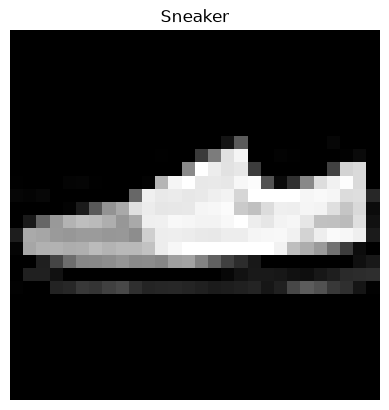

In [15]:
train_features , train_labels = next(iter(train_dataloader))
print(f"Features batch shape: {train_features.shape}")
print(f"Labels batch shape: {train_labels.shape}")
img = train_features[0].squeeze()
labels = train_labels[0]
plt.title(labels_map[labels.item()])
plt.imshow(img, cmap = "gray")
plt.axis("off")

plt.show()


### Dropout 

In [2]:
import torch 
import torch.nn as nn

In [10]:
dropout = nn.Dropout(p=0.1)

x  = torch.tensor([
    [1.0, 2.0, 3.0, 4.0],
    [5.0, 6.0, 7.0, 8.0]
])

dropout.train()
y_train = dropout(x)

print(y_train)

tensor([[0.0000, 2.2222, 3.3333, 4.4444],
        [5.5556, 6.6667, 7.7778, 0.0000]])


In [9]:
dropout.eval()

y_test = dropout(x)

y_test

tensor([[1., 2., 3., 4.],
        [5., 6., 7., 8.]])

In [ ]:


class MyDropput(nn.Module):
    def __init__(self, p=0.1):
        super().__init__()

        if not 0<=p<1:
            raise ValueError
        
        self.p = p
    
    def forward(self,x):
        if not self.training or self.p ==0:
            return X

        keep_prob = 1-self.p

        mask = (
            torch.rand_like(x) < keep_prob
        ).to(x.dtype)

        return x*mask/keep_prob

### Label Smoothing 

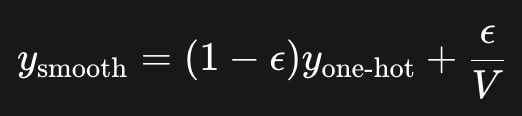

In [ ]:
# criterion = nn.CrossEntropyLoss(
#     label_smoothing=0.1,
# )